# Week 14 Lab: Bootstrap Confidence Intervals

**CE 310 — Probability & Statistics for Civil & Architectural Engineering**  
**University of Arizona**

---

Bootstrap resampling lets you estimate the uncertainty of any statistic — no distributional assumptions required. You will apply it to the DOE medical office dataset and compare bootstrap CIs to the analytical CIs you computed in Weeks 9–11.

**Key concept:** Bootstrap resamples from the *data itself* (with replacement) to estimate the sampling distribution of any statistic. Compare to Week 13 Monte Carlo: MC samples from *assumed distributions* for inputs; bootstrap samples from *observed data* to quantify uncertainty in estimated statistics.

---

**Grading:**  
- Section A: 8 numeric answers × 2 pts = **16 pts**  
- Section B: 8 numeric answers × 4 pts = **32 pts**  
- Written interpretations: **12 pts**  
- **Total: 60 pts**

## Before You Begin

**File needed:** `Week5_DOE_MedOffice_ZoneTemp_2023.csv`  
This is the same dataset from Weeks 5–7 (Excel) and Weeks 9–12 (Python).

**Upload options:**
1. **Colab Files panel (easiest):** Click the folder icon in the left sidebar → click the upload icon → select the CSV file from your computer.
2. **Google Drive mount:** Click the Drive mount button in the Files panel and navigate to the file.

> If you see `FileNotFoundError`, the CSV is not in Colab's working directory — go back and upload it first.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

%matplotlib inline

In [ ]:
N_BOOT = 1000
SEED   = 42
THRESHOLD_KWH = 30

df = pd.read_csv('Week5_DOE_MedOffice_ZoneTemp_2023.csv')
df['BH'] = (df['BusinessHours'] == 'Yes').astype(int)
n = len(df)
rng = np.random.default_rng(SEED)
print(f"Rows: {n} | Mean Outdoor_Temp_F: {df['Outdoor_Temp_F'].mean():.2f}°F | Mean Cooling_kWh: {df['Cooling_kWh'].mean():.2f}")

## Section A — Bootstrap Confidence Intervals: Fundamentals

> **How a bootstrap CI is built:**  
> Draw *n* observations **with replacement** from your data **N_BOOT** times.  
> Each resample gives one estimate of your statistic.  
> The 2.5th and 97.5th percentiles of those N_BOOT estimates form the **95% CI**.
>
> No assumptions about normality or known variance — the data speaks for itself.

### A1–A4: Bootstrap CI for Mean Outdoor Temperature

Compute 1000 bootstrap sample means, then find the 95% percentile CI. Compare to the analytical t-interval.

In [ ]:
boot_means_T = np.array([df['Outdoor_Temp_F'].iloc[rng.integers(0, n, n)].mean() for _ in range(N_BOOT)])

ANSWER_A1 = round(boot_means_T.mean(), 3)
ANSWER_A2 = round(boot_means_T.std(), 5)
ANSWER_A3 = round(np.percentile(boot_means_T, 2.5), 3)
ANSWER_A4 = round(np.percentile(boot_means_T, 97.5), 3)

print(f"ANSWER_A1 = {ANSWER_A1}")
print(f"ANSWER_A2 = {ANSWER_A2}")
print(f"ANSWER_A3 = {ANSWER_A3}")
print(f"ANSWER_A4 = {ANSWER_A4}")

t_ci = stats.t.interval(0.95, df=n-1,
                        loc=df['Outdoor_Temp_F'].mean(),
                        scale=stats.sem(df['Outdoor_Temp_F']))
print(f"\nBootstrap 95% CI : [{ANSWER_A3}, {ANSWER_A4}]")
print(f"Analytical t-CI  : [{round(t_ci[0],3)}, {round(t_ci[1],3)}]")

**Target shape:**

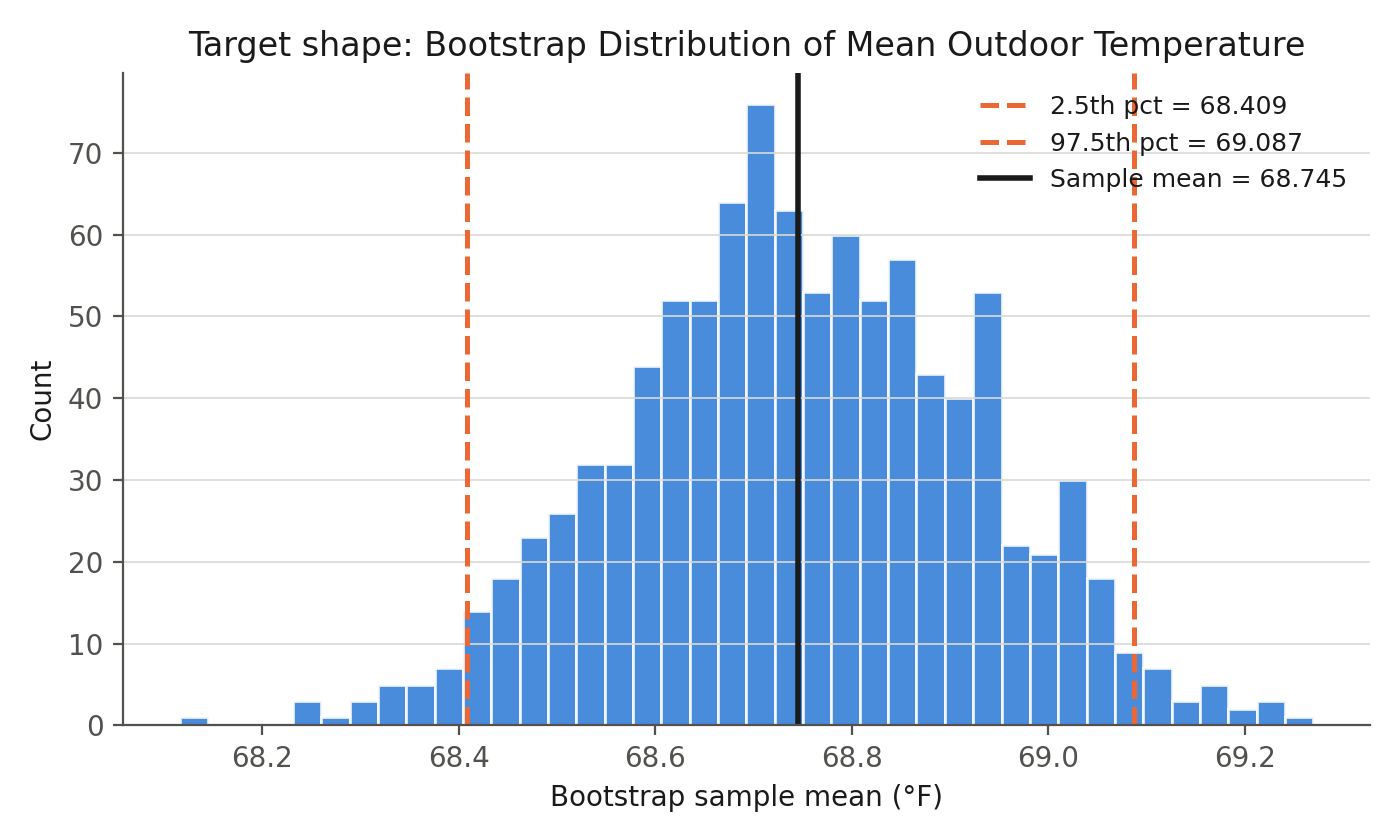


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_means_T, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(ANSWER_A3, color='crimson', linestyle='--', linewidth=1.5, label=f'2.5th pct = {ANSWER_A3}')
ax.axvline(ANSWER_A4, color='crimson', linestyle='--', linewidth=1.5, label=f'97.5th pct = {ANSWER_A4}')
ax.axvline(df['Outdoor_Temp_F'].mean(), color='black', linestyle='-', linewidth=2, label=f'Sample mean = {df["Outdoor_Temp_F"].mean():.3f}')
ax.set_xlabel('Bootstrap sample mean (°F)')
ax.set_ylabel('Count')
ax.set_title('Bootstrap Distribution of Mean Outdoor Temperature')
ax.legend()
plt.tight_layout()
plt.show()

### A5–A6: Bootstrap CI for the 95th Percentile of Cooling

The P95 of `Cooling_kWh` is used as a design sizing criterion (ASHRAE 90.1). Bootstrap gives you a CI on that design value — useful when you need to communicate uncertainty around a peak-load estimate.

In [ ]:
boot_p95 = np.array([np.percentile(df['Cooling_kWh'].iloc[rng.integers(0, n, n)].values, 95) for _ in range(N_BOOT)])

ANSWER_A5 = round(np.percentile(boot_p95, 2.5), 2)
ANSWER_A6 = round(np.percentile(boot_p95, 97.5), 2)

print(f"ANSWER_A5 = {ANSWER_A5}")
print(f"ANSWER_A6 = {ANSWER_A6}")

obs_p95 = np.percentile(df['Cooling_kWh'], 95)
print(f"\nObserved P95 Cooling_kWh : {obs_p95:.2f} kWh")
print(f"Bootstrap 95% CI for P95 : [{ANSWER_A5}, {ANSWER_A6}] kWh")

### A7–A8: Bootstrap CI for the Regression Slope

Use the **pairs bootstrap**: resample rows *(x_i, y_i)* together to preserve the joint structure, then refit OLS each time. This captures dependence between predictor and response without assuming homoscedasticity.

In [ ]:
boot_slopes = []
for _ in range(N_BOOT):
    idx = rng.integers(0, n, n)
    df_b = df.iloc[idx]
    m_b = smf.ols('Cooling_kWh ~ Outdoor_Temp_F', data=df_b).fit()
    boot_slopes.append(m_b.params['Outdoor_Temp_F'])
boot_slopes = np.array(boot_slopes)

ANSWER_A7 = round(np.percentile(boot_slopes, 2.5), 4)
ANSWER_A8 = round(np.percentile(boot_slopes, 97.5), 4)

print(f"ANSWER_A7 = {ANSWER_A7}")
print(f"ANSWER_A8 = {ANSWER_A8}")

m1 = smf.ols('Cooling_kWh ~ Outdoor_Temp_F', data=df).fit()
ols_ci = m1.conf_int().loc['Outdoor_Temp_F']
ols_ci_lower = ols_ci[0]
ols_ci_upper = ols_ci[1]
print(f"\nBootstrap 95% CI for slope : [{ANSWER_A7}, {ANSWER_A8}]")
print(f"Analytical OLS 95% CI      : [{round(ols_ci_lower,4)}, {round(ols_ci_upper,4)}]")

## Section B — Bootstrap for Model Diagnostics

Section B extends bootstrap to the two-predictor model (`Cooling_kWh ~ Outdoor_Temp_F + BH`), permutation testing, and exceedance probability estimation.

### B1–B4: Bootstrap CI for BH Coefficient and R²

Fit Model 2 (`Cooling_kWh ~ Outdoor_Temp_F + BH`) on each bootstrap resample. Record the BH coefficient and R² to build CIs for both.

In [ ]:
boot_BH = []
boot_R2 = []
for _ in range(N_BOOT):
    idx = rng.integers(0, n, n)
    df_b = df.iloc[idx]
    m_b = smf.ols('Cooling_kWh ~ Outdoor_Temp_F + BH', data=df_b).fit()
    boot_BH.append(m_b.params['BH'])
    boot_R2.append(m_b.rsquared)
boot_BH = np.array(boot_BH)
boot_R2 = np.array(boot_R2)

ANSWER_B1 = round(np.percentile(boot_BH, 2.5), 3)
ANSWER_B2 = round(np.percentile(boot_BH, 97.5), 3)
ANSWER_B3 = round(np.mean(boot_R2), 4)
ANSWER_B4 = round(np.percentile(boot_R2, 2.5), 4)

print(f"ANSWER_B1 = {ANSWER_B1}")
print(f"ANSWER_B2 = {ANSWER_B2}")
print(f"ANSWER_B3 = {ANSWER_B3}")
print(f"ANSWER_B4 = {ANSWER_B4}")

m2 = smf.ols('Cooling_kWh ~ Outdoor_Temp_F + BH', data=df).fit()
ols_bh_ci = m2.conf_int().loc['BH']
print(f"\nBootstrap 95% CI for BH coef : [{ANSWER_B1}, {ANSWER_B2}]")
print(f"Analytical OLS 95% CI for BH : [{round(ols_bh_ci[0],3)}, {round(ols_bh_ci[1],3)}]")
print(f"CI includes zero? Bootstrap: {ANSWER_B1 <= 0 <= ANSWER_B2} | OLS: {ols_bh_ci[0] <= 0 <= ols_bh_ci[1]}")

**Interpretation (written_B1):** The bootstrap 95% CI for the BH coefficient is [ANSWER_B1, ANSWER_B2]. Does this interval include zero? Compare its width to the analytical OLS 95% CI for BH. What does a wider (or narrower) bootstrap CI suggest about the distribution of the BH estimator? (3–4 sentences)

YOUR INTERPRETATION HERE

### B5: Permutation Test — Is the BH Effect Real?

A permutation test asks: if BH had no effect on cooling, how often would we see a mean difference as large as the observed one? Shuffle the BH labels and recompute the statistic N_BOOT times.

In [ ]:
bh_yes   = df.loc[df['BH']==1, 'Cooling_kWh'].values
bh_no    = df.loc[df['BH']==0, 'Cooling_kWh'].values
obs_diff = bh_yes.mean() - bh_no.mean()
combined = np.concatenate([bh_yes, bh_no])
n_yes    = len(bh_yes)

perm_diffs = []
for _ in range(N_BOOT):
    shuffled = rng.permutation(combined)
    perm_diffs.append(shuffled[:n_yes].mean() - shuffled[n_yes:].mean())
perm_diffs = np.array(perm_diffs)

ANSWER_B5 = round(np.mean(np.abs(perm_diffs) >= np.abs(obs_diff)), 4)

print(f"ANSWER_B5 = {ANSWER_B5}")

t_stat, t_pval = stats.ttest_ind(bh_yes, bh_no)
print(f"\nObserved mean difference (BH=1 minus BH=0): {obs_diff:.3f} kWh")
print(f"Permutation test p-value : {ANSWER_B5}")
print(f"Parametric t-test p-value: {t_pval:.4e}")

**Comparison (written_B2):** The parametric t-test (Week 11) gave a p-value near zero. The permutation test gives ANSWER_B5. Do they agree? Explain in one sentence why both p-values are effectively zero for this dataset, and name one scenario where a permutation test would give a meaningfully different answer than a t-test. (3–4 sentences)

YOUR COMPARISON HERE

### B6–B7: Bootstrap CI for an Exceedance Probability

Bootstrap can estimate the uncertainty in any statistic — including a probability. Here you estimate P(Cooling > THRESHOLD_KWH) and its 95% CI.

In [ ]:
boot_prob = np.array([(df['Cooling_kWh'].iloc[rng.integers(0, n, n)].values > THRESHOLD_KWH).mean() for _ in range(N_BOOT)])

ANSWER_B6 = round(np.percentile(boot_prob, 2.5), 4)
ANSWER_B7 = round(np.percentile(boot_prob, 97.5), 4)

print(f"ANSWER_B6 = {ANSWER_B6}")
print(f"ANSWER_B7 = {ANSWER_B7}")

obs_prob = (df['Cooling_kWh'] > THRESHOLD_KWH).mean()
print(f"\nObserved P(Cooling > {THRESHOLD_KWH} kWh) : {obs_prob:.4f}")
print(f"Bootstrap 95% CI              : [{ANSWER_B6}, {ANSWER_B7}]")

### B8: Bootstrap vs Analytical CI Width

Compare the width of the bootstrap CI for the Model 1 slope (A7–A8) to the analytical OLS CI. A ratio > 1 means the bootstrap CI is wider, suggesting the OLS standard errors may understate uncertainty (e.g., due to heteroscedasticity or non-normality of residuals).

In [ ]:
ols_ci_width  = ols_ci_upper - ols_ci_lower
boot_ci_width = ANSWER_A8 - ANSWER_A7

ANSWER_B8 = round(boot_ci_width / ols_ci_width, 3)

print(f"ANSWER_B8 = {ANSWER_B8}")

print(f"\nBootstrap CI width : {boot_ci_width:.4f}")
print(f"OLS CI width       : {ols_ci_width:.4f}")
print(f"Ratio              : {ANSWER_B8}")
if ANSWER_B8 > 1:
    print("Ratio > 1 — bootstrap CI is wider → OLS standard errors may understate uncertainty")
else:
    print("Ratio ≤ 1 — bootstrap CI is narrower or equal to OLS CI")

## Section C — When to Use Bootstrap

Bootstrap is most valuable when parametric assumptions are questionable or when the statistic of interest has no closed-form sampling distribution.

**Reflection (written_reflection):** Name two situations in civil or architectural engineering where bootstrap CIs would be more appropriate than standard parametric CIs (t-interval or OLS standard errors). For each situation, explain what assumption the parametric method makes that bootstrap avoids. (4–6 sentences)

YOUR REFLECTION HERE

---
## Before You Submit

> ⚠️ Your saved cell **outputs** are what get read, not your code. If you skip this step, every numeric question scores 0 — even if your formulas are correct.

**Step 1 — Run All Cells:**
In the menu bar: **Runtime → Run all** (Google Colab) or **Kernel → Restart & Run All** (Jupyter).
Wait until every cell shows output — no spinning circles.

**Step 2 — Check your ANSWER_ lines:**
Each graded cell should print a line like `ANSWER_A1 = 23.45`. If any prints `None` or is missing, fix the code and re-run.

**Step 3 — Download and upload:**
- File → Download → **Download .ipynb** (not PDF, not .py)
- Rename: `lastname_firstname_week14.ipynb`
- Upload to D2L before the deadline

**Submission checklist:**
- [ ] All cells ran without error (no red tracebacks)
- [ ] Every `ANSWER_` variable prints a number (not `None`)
- [ ] Memo paragraphs are filled in (not placeholder text)
- [ ] File downloaded as `.ipynb` — not PDF, not `.py`
- [ ] File renamed: `lastname_firstname_week14.ipynb`
